# RETrace2 Tutorial: Running Test Data

This tutorial demonstrates how to run RETrace2 with the provided test dataset and interpret the results.

## Prerequisites

- Docker installed and running
- RETrace2 repository cloned
- Test data available in `data/` directory


# 1. Running the Test Data

The test dataset consists of 3 samples and includes both microsatellite and methylation data. Here's the command to run the complete analysis:


```
#!/bin/bash
nextflow run main.nf --samplesheet assets/samplesheet_msh2.csv \
                     --output_dir results \
                     --output_prefix 20250427_msh2_female \
                     --genome_base /home/tcheng/Projects/GenomeDB \
                     --genome mm39 \
                     --target_bed /home/tcheng/software/RETrace2/resources/targets/mm39/RETrace2.mm39.1nt10-30bp.92460targets169818probes.bed \
                     -profile docker \

                    # below are the optional parameters
                     --threads 10 \    
                     --run_bootstrap \
                     --run_methylation \
                     --celltype_ref_dir /home/tcheng/Projects/RETrace/Methylation_ref/Ref_Combined/Ref_Combined_ChromHMM_mTSS_mEnhA_mEnhWk_mBivProm \
                     --celltype_ref_pattern "Brain_CB*tsv" \
                     -resume \
````

### Expected execution output:
```
 N E X T F L O W   ~  version 25.04.6

Launching `main.nf` [spontaneous_watson] DSL2 - revision: 65f7506bf3


===========================================
 RETrace2 Pipeline v1.0
===========================================
Samplesheet        : assets/samplesheet_msh2.csv
Output directory   : results
Reference genome   : mm39
Profile            : docker
Sequencing mode    : Single-end
Threads            : 10
Memory             : 16.GB
Per Sample parameters:
  - Min targets    : 100
  - Min CpGs       : 0
HipSTR parameters  :
  - Path           : HipSTR (from PATH)
  - Min quality    : 0.9
  - Min reads      : 10
  - Max stutter    : 1
Phylogenetic parameters:
  - Distance metric: minComp_EqorNot
  - Outgroup       : Midpoint
  - Color background: true
  - Circular layout: false
Optional analyses  :
  - Bootstrap      : true
  - Evaluation     : false
  - Methylation    : true
===========================================

executor >  local (75)
[90/6752f2] process > MAPPING:FASTQC (3)                 [100%] 3 of 3 ✔
[3d/6c0c51] process > MAPPING:MULTIQC                    [100%] 1 of 1 ✔
[63/595834] process > MAPPING:TRIM_GALORE (1)            [100%] 3 of 3 ✔
[9e/48ebf8] process > MAPPING:BWA_MEM (1)                [100%] 3 of 3 ✔
[d0/c010e7] process > METHYLATION:METH_FASTQC (3)        [100%] 3 of 3 ✔
[54/13a100] process > METHYLATION:METH_MULTIQC           [100%] 1 of 1 ✔
[6d/5be9f1] process > METHYLATION:METH_TRIM_GALORE (2)   [100%] 3 of 3 ✔
[7e/ae86dc] process > METHYLATION:METHYLPY (1)           [100%] 3 of 3 ✔
[b9/b33407] process > STATS:COUNT_TARGETS (3)            [100%] 3 of 3 ✔
[fa/478243] process > STATS:COMBINE_STATS                [100%] 1 of 1 ✔
[f0/a17f6e] process > HIPSTR:FILTER_BAMS_BY_STATS (1)    [100%] 3 of 3 ✔
[d2/103f5f] process > HIPSTR:HIPSTR_PER_CHROM (chr9)     [100%] 42 of 42 ✔
[fc/a60358] process > HIPSTR:MERGE_VCFS                  [100%] 1 of 1 ✔
[1f/450772] process > HIPSTR:PARSE_VCF                   [100%] 1 of 1 ✔
[e5/7a44c3] process > PHYLO:BUILD_TREE                   [100%] 1 of 1 ✔
[21/1ee65d] process > PHYLO:VIEW_PHYLO (1)               [100%] 1 of 1 ✔
[cd/9b0384] process > INFER_CELLTYPE:CALCULATE_PD_MATRIX [100%] 1 of 1 ✔
[cc/a39cea] process > INFER_CELLTYPE:ASSIGN_CELLTYPE     [100%] 1 of 1 ✔
Pipeline completed at: 2025-07-21T00:34:21.692448840Z
Execution status: SUCCESS
Execution duration: 2m 58s

        ===========================================
         RETrace2 Pipeline - COMPLETED SUCCESSFULLY
        ===========================================
        Results are available in: results
        
        Core results:
        - Microsatellite FASTQC: results/mapping/fastqc/
        - Microsatellite BAM files: results/mapping/bam/
        - Microsatellite statistics: results/stats/ms_counts/
        - Summary statistics: results/stats/
        - HipSTR genotyping: results/hipstr/
        - Phylogenetic tree: results/phylo/newick-orginal.txt
        

        Bootstrap results:
        - Support values: results/phylo/bootstrap_stats.txt
        - Bootstrap trees: results/phylo/newwick-bootstrap.txt
            

        Methylation results:
        - Methylation FASTQC: results/methylation/fastqc/
        - Methylation allc files: results/methylation/methylpy/
        - Combined statistics: results/stats/ (includes both MS and CpG data)
            

        Cell type inference results:
        - Pairwise dissimilarity matrix: results/infer_celltype/pd_matrix/
        - Cell type assignments: results/infer_celltype/assignments/
        - Z-score matrix: results/infer_celltype/assignments/
        - Cell type plots: results/infer_celltype/assignments/
                
===========================================
Completed at: 21-Jul-2025 00:34:21
Duration    : 2m 58s
CPU hours   : 1.3
Succeeded   : 75
```


# 2. Results


## Stats Module

In [1]:
import pandas as pd

# Read per sample stats
stats = pd.read_csv('../results/stats/sample_stats.tsv', sep='\t')
stats.head()


,sample_id,ms_targets_with_min_reads,cpg_count,pass
0,Brain-PostCortex-NeuNpos-4F,11028,3647,True
1,Brain-PostCortex-NeuNpos-5F,10818,3675,True
2,Kidney-Cortex-1-7C,10746,5821,True


In [2]:
# Read summary stats
with open("../results/stats/summary_stats.txt", "r") as file:
    print(file.read())

Filter Parameters:
Minimum reads per target: 10
Minimum targets per sample: 100
Minimum CpGs per sample: 0

Sample Counts:
Total samples: 3
Passing samples: 3
Failed samples: 0

All Samples Statistics:
Mean microsatellite targets (with min reads): 10864.00
Median microsatellite targets (with min reads): 10818.00
Mean CpG count: 4381.00
Median CpG count: 3675.00
Mean CpG methylation rate: 0.4097
Median CpG methylation rate: 0.3693

Filtered Samples Statistics:
Mean microsatellite targets (with min reads): 10864.00
Median microsatellite targets (with min reads): 10818.00
Mean CpG count: 4381.00
Median CpG count: 3675.00
Mean CpG methylation rate: 0.4097
Median CpG methylation rate: 0.3693



In [3]:
from IPython.display import display, HTML

png1 = "../results/stats/figures/ms_targets_barplot.png"
png2 = "../results/stats/figures/cpg_count_barplot.png"

# HTML with flexbox for side-by-side display
html = f"""
<div style="display: flex; gap: 10px;">
    <img src="{png1}" width="45%">
    <img src="{png2}" width="45%">
</div>
"""
display(HTML(html))

## Phylo Tree Module
- If --run_bootstrap is specified (optional), the pipeline will run the bootstrap analysis.
- This could take a long time to run if sample size is large. 
- You can set the number of bootstrap iterations with --bootstrap_iterations. (Default: 100)
- The red color numbers in the tree are the bootstrap support values for each node.

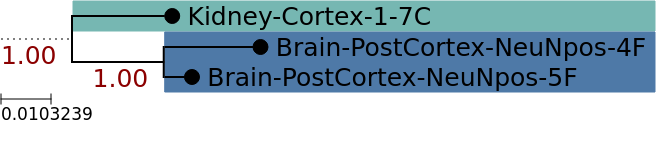

In [4]:
from IPython.display import Image
display(Image("../results/phylo/20250427_msh2_female.viewPhylo.png"))

## Methylation - Infer Cell Type Module
- If --run_methylation is specified, the pipeline will run the methylation analysis. 
- This pipeline is optional, run only if you have dual-omic data (microsatellite and methylation).
- Test data run is only using 2 reference cell types as example. So the cell type inference is not accurate.
- See [notebooks/Fig4_Methylation_Infer_CellType.ipynb](notebooks/Fig4_Methylation_Infer_CellType.ipynb) for demonstration using real postive control data.


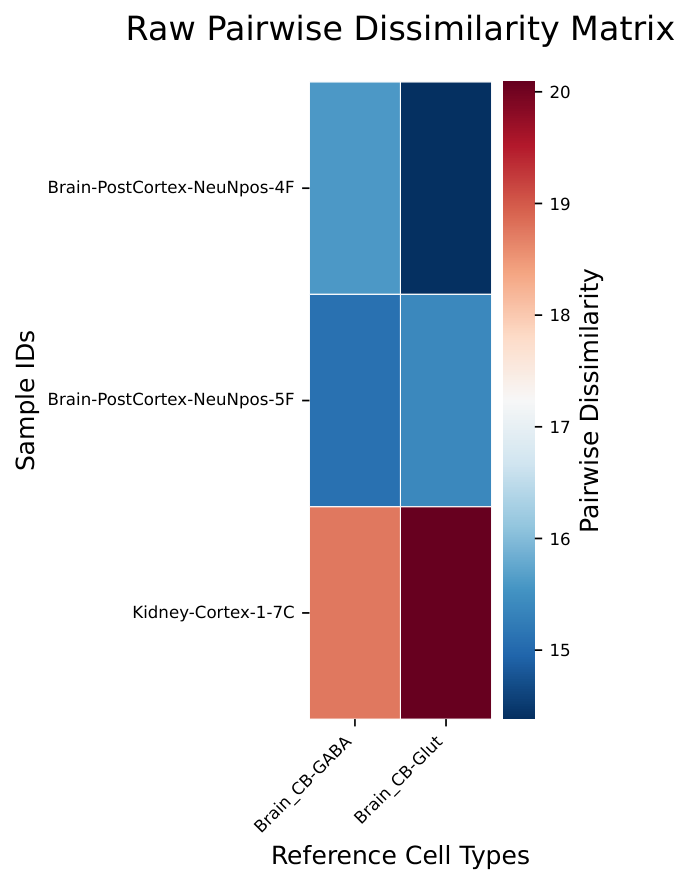
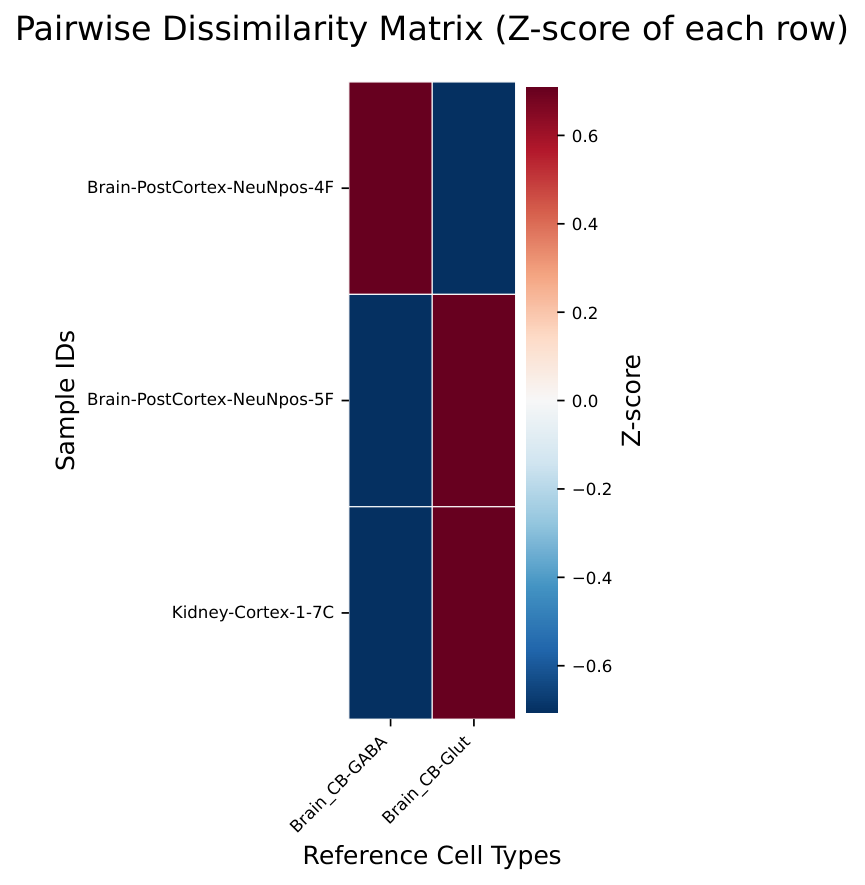

In [5]:
import fitz
from IPython.display import display, HTML
from base64 import b64encode

pdf1 = "../results/infer_celltype/assignments/raw_pd_matrix.pdf"
pdf2 = "../results/infer_celltype/assignments/zscore_pd_matrix.pdf"

def pdf_to_img(pdf_path):
    pdf = fitz.open(pdf_path)
    page = pdf.load_page(0)
    # Use zoom to maintain aspect ratio, scale to similar size
    zoom = 150 / 72  # 150 DPI
    pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))
    img_data = b64encode(pix.tobytes("png")).decode('utf-8')
    pdf.close()
    return img_data

img1 = pdf_to_img(pdf1)
img2 = pdf_to_img(pdf2)

html = f"""
<div style="display: flex; gap: 10px; justify-content: center;">
    <img src="data:image/png;base64,{img1}" style="max-width: 38%; height: auto; object-fit: contain;">
    <img src="data:image/png;base64,{img2}" style="max-width: 45%; height: auto; object-fit: contain;">
</div>
"""
display(HTML(html))

In [6]:
# View cell type assignments
celltype_assignments = pd.read_csv('../results/infer_celltype/assignments/celltype_assignments.tsv', sep='\t')
celltype_assignments.head()

,Sample_ID,Best_Match,Min_Zscore,Second_Best_Match,Second_Best_Zscore,Passes_Threshold,Assignment
0,Brain-PostCortex-NeuNpos-4F,Brain_CB-Glut,-0.707107,Brain_CB-GABA,0.707107,False,Unassigned
1,Brain-PostCortex-NeuNpos-5F,Brain_CB-GABA,-0.707107,Brain_CB-Glut,0.707107,False,Unassigned
2,Kidney-Cortex-1-7C,Brain_CB-GABA,-0.707107,Brain_CB-Glut,0.707107,False,Unassigned
